<style>
:root{--navy:#102a43;--blue:#184e77;--teal:#2a9d8f;--gold:#e9b949;--red:#d95d39;--ink:#172033;--muted:#5f6f7f;--pale:#edf5fb}
.eda-section{margin:28px 0 14px;padding:16px 22px;border-radius:14px;background:linear-gradient(90deg,#102a43,#184e77);color:#fff;box-shadow:0 7px 20px rgba(16,42,67,.15);font-family:Inter,'Segoe UI',Arial,sans-serif}.eda-section h2{margin:0;color:#fff;border:0;font-size:22px}.eda-call{margin:14px 0;padding:18px 22px;border:1px solid #c9d9e6;border-left:6px solid #2a9d8f;border-radius:13px;background:#edf5fb;color:#172033;line-height:1.7}.eda-call.gold{border-left-color:#e9b949;background:#fff9e9}.eda-call.red{border-left-color:#d95d39;background:#fff2ed}.eda-grid{display:grid;grid-template-columns:repeat(auto-fit,minmax(160px,1fr));gap:10px;margin:14px 0}.eda-metric{padding:13px;border:1px solid #c9e7e0;border-radius:11px;background:#e8f6f3;color:#184e77;text-align:center}.eda-metric b{display:block;font-size:22px}.jp-RenderedHTMLCommon th{background:#184e77!important;color:white!important;text-align:left!important}.jp-RenderedHTMLCommon td,.jp-RenderedHTMLCommon th{padding:8px!important}
</style>
<div style="box-sizing:border-box;width:100%;margin:12px 0 26px;padding:38px 42px;border:1px solid rgba(255,255,255,.18);border-radius:24px;color:#f8fbff;font-family:Inter,'Segoe UI',Arial,sans-serif;background:radial-gradient(circle at 92% 8%,rgba(255,255,255,.16) 0 8%,transparent 9%),linear-gradient(125deg,#102a43 0%,#184e77 56%,#2a9d8f 100%);box-shadow:0 16px 38px rgba(16,42,67,.28);overflow:hidden;">
  <div style="display:flex;flex-wrap:wrap;gap:8px;margin-bottom:18px;">
    <span style="padding:6px 13px;border:1px solid rgba(255,255,255,.34);border-radius:999px;background:rgba(255,255,255,.13);font-size:11px;font-weight:800;">DEEP LEARNING</span>
    <span style="padding:6px 13px;border:1px solid rgba(255,255,255,.34);border-radius:999px;background:rgba(255,255,255,.13);font-size:11px;font-weight:800;">LABORATORIO 05</span>
    <span style="padding:6px 13px;border:1px solid rgba(255,255,255,.34);border-radius:999px;background:rgba(255,255,255,.13);font-size:11px;font-weight:800;">EDA</span>
    <span style="padding:6px 13px;border:1px solid rgba(255,255,255,.34);border-radius:999px;background:rgba(255,255,255,.13);font-size:11px;font-weight:800;">RETO BABEL</span>
  </div>
  <div style="font-size:38px;font-weight:820;line-height:1.15;">Análisis exploratorio del idioma Babel</div>
  <div style="max-width:950px;margin-top:10px;color:rgba(255,255,255,.88);font-size:20px;line-height:1.5;">Integridad, cobertura léxica, dificultad gramatical y evidencia para orientar la siguiente iteración del Transformer</div>
  <div style="width:74px;height:4px;margin:22px 0;background:#e9b949;border-radius:999px;"></div>
  <div style="display:grid;grid-template-columns:repeat(auto-fit,minmax(210px,1fr));gap:12px;">
    <div style="padding:14px 16px;border:1px solid rgba(255,255,255,.25);border-radius:12px;background:rgba(255,255,255,.09);"><b>Institución</b><br>Universidad del Valle de Guatemala</div>
    <div style="padding:14px 16px;border:1px solid rgba(255,255,255,.25);border-radius:12px;background:rgba(255,255,255,.09);"><b>Curso</b><br>Deep Learning y Sistemas Inteligentes</div>
    <div style="padding:14px 16px;border:1px solid rgba(255,255,255,.25);border-radius:12px;background:rgba(255,255,255,.09);"><b>Integrante</b><br>Pablo Daniel Barillas Moreno · 22193</div>
    <div style="padding:14px 16px;border:1px solid rgba(255,255,255,.25);border-radius:12px;background:rgba(255,255,255,.09);"><b>Integrante</b><br>Cindy Mishelle Gualim Pérez · 221226</div>
    <div style="padding:14px 16px;border:1px solid rgba(255,255,255,.25);border-radius:12px;background:rgba(255,255,255,.09);"><b>Datos</b><br>22 palabras · 1,200 train · 240 validación</div>
    <div style="padding:14px 16px;border:1px solid rgba(255,255,255,.25);border-radius:12px;background:rgba(255,255,255,.09);"><b>Propósito</b><br>Decidir con evidencia antes de aumentar capacidad</div>
  </div>
</div>


<div class="eda-section"><h2>1 · Objetivo y preguntas del EDA</h2></div>
<div class="eda-call">El análisis no busca optimizar hiperparámetros todavía. Primero verifica si existen duplicados, fuga, OOV, desbalance léxico o subgrupos gramaticales que expliquen los errores.</div>


Se responden cinco preguntas:

1. ¿Las particiones contienen ejemplos únicos y separados?
2. ¿Validación introduce palabras o longitudes no vistas?
3. ¿Negación, adjetivos o determinantes generan subgrupos desbalanceados?
4. ¿Los errores parecen léxicos o estructurales?
5. ¿La siguiente mejora debe concentrarse en datos, entrenamiento, inferencia o capacidad?


In [1]:
from collections import Counter
import csv
import html
import json
import statistics
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import HTML, display

def buscar_raiz(inicio=Path.cwd()):
    for candidato in [inicio, *inicio.parents]:
        if (candidato / "datos" / "CARPETA_DATOS" / "entrenamiento.csv").exists():
            return candidato
    raise FileNotFoundError("No se encontró datos/CARPETA_DATOS desde el directorio actual.")

def leer_csv(ruta):
    with ruta.open(encoding="utf-8", newline="") as archivo:
        return list(csv.DictReader(archivo))

def mostrar_tabla(encabezados, filas):
    head = "".join(f"<th>{html.escape(str(x))}</th>" for x in encabezados)
    body = "".join("<tr>" + "".join(f"<td>{html.escape(str(x))}</td>" for x in fila) + "</tr>" for fila in filas)
    display(HTML(f"<table><thead><tr>{head}</tr></thead><tbody>{body}</tbody></table>"))

RAIZ = buscar_raiz()
DATOS = RAIZ / "datos" / "CARPETA_DATOS"
FIGURAS = RAIZ / "evidencia" / "figuras"
FIGURAS.mkdir(parents=True, exist_ok=True)

diccionario = leer_csv(DATOS / "diccionario.csv")
train = leer_csv(DATOS / "entrenamiento.csv")
validacion = leer_csv(DATOS / "validacion.csv")
print("Raíz:", RAIZ)
print("Archivos cargados correctamente.")

Raíz: C:\Users\Daniel Barillas\Desktop\Laboratorio-5_Deep-Learning
Archivos cargados correctamente.


<div class="eda-section"><h2>2 · Inventario e integridad</h2></div>
<div class="eda-call">Se comprueban esquemas, unicidad, traslape y cobertura antes de interpretar cualquier métrica del modelo.</div>

In [2]:
columnas_esperadas = {"idioma_secreto", "espanol"}
assert set(train[0]) == columnas_esperadas
assert set(validacion[0]) == columnas_esperadas
assert set(diccionario[0]) == {"token_secreto", "significado"}

pares_train = {(r["idioma_secreto"], r["espanol"]) for r in train}
pares_val = {(r["idioma_secreto"], r["espanol"]) for r in validacion}
src_train = {r["idioma_secreto"] for r in train}
src_val = {r["idioma_secreto"] for r in validacion}

integridad = [
    ("Diccionario", len(diccionario), len({r['token_secreto'] for r in diccionario}), "OK"),
    ("Entrenamiento", len(train), len(pares_train), "OK" if len(train)==len(pares_train) else "Duplicados"),
    ("Validación", len(validacion), len(pares_val), "OK" if len(validacion)==len(pares_val) else "Duplicados"),
    ("Traslape train/validación", len(src_train & src_val), 0, "OK" if not src_train & src_val else "Revisar"),
]
mostrar_tabla(["Indicador", "Observado", "Esperado/únicos", "Estado"], integridad)
assert len(src_train & src_val) == 0
print("OK - no hay repetición de frases entre particiones")

Indicador,Observado,Esperado/únicos,Estado
Diccionario,22,22,OK
Entrenamiento,1200,1200,OK
Validación,240,240,OK
Traslape train/validación,0,0,OK


OK - no hay repetición de frases entre particiones


<div class="eda-call gold"><b>Conclusión de integridad.</b> Las 1,440 frases son únicas y validación no repite entradas de entrenamiento. Por tanto, la exactitud de validación no puede explicarse por duplicados exactos.</div>

<div class="eda-section"><h2>3 · Vocabulario y cobertura</h2></div>
<div class="eda-call">Se verifica si los errores pueden atribuirse a palabras desconocidas o frecuencias extremadamente bajas.</div>

Espacio,Vocabulario train,Vocabulario validación,OOV validación
Secreto,22,22,[]
Español,22,22,[]


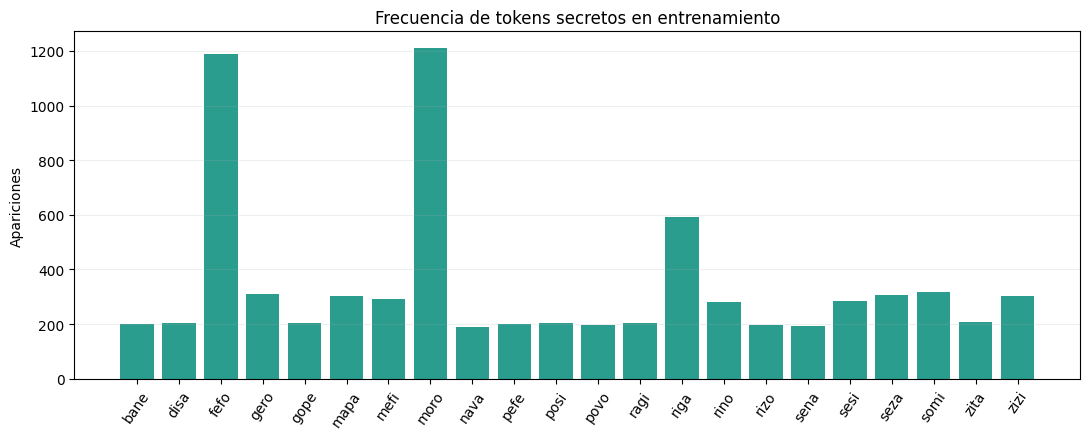

In [3]:
tokens_src_train = [t for r in train for t in r["idioma_secreto"].split()]
tokens_src_val = [t for r in validacion for t in r["idioma_secreto"].split()]
tokens_tgt_train = [t for r in train for t in r["espanol"].split()]
tokens_tgt_val = [t for r in validacion for t in r["espanol"].split()]

vocab_src_train, vocab_src_val = set(tokens_src_train), set(tokens_src_val)
vocab_tgt_train, vocab_tgt_val = set(tokens_tgt_train), set(tokens_tgt_val)
oov_src = sorted(vocab_src_val - vocab_src_train)
oov_tgt = sorted(vocab_tgt_val - vocab_tgt_train)

mostrar_tabla(
    ["Espacio", "Vocabulario train", "Vocabulario validación", "OOV validación"],
    [("Secreto", len(vocab_src_train), len(vocab_src_val), oov_src),
     ("Español", len(vocab_tgt_train), len(vocab_tgt_val), oov_tgt)],
)
assert not oov_src and not oov_tgt

freq = Counter(tokens_src_train)
orden = [r["token_secreto"] for r in diccionario]
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(orden, [freq[t] for t in orden], color="#2a9d8f")
ax.set_title("Frecuencia de tokens secretos en entrenamiento")
ax.set_ylabel("Apariciones"); ax.tick_params(axis="x", rotation=55); ax.grid(axis="y", alpha=.2)
fig.tight_layout(); fig.savefig(FIGURAS / "eda_frecuencias_tokens.png", dpi=180, bbox_inches="tight"); plt.show()

<div class="eda-call"><b>Lectura.</b> No existen OOV. Los determinantes aparecen con mayor frecuencia porque cada frase contiene dos sintagmas nominales; la negación aparece aproximadamente en la mitad. Ningún token de contenido está ausente o es excepcionalmente raro.</div>

<div class="eda-section"><h2>4 · Longitudes y complejidad superficial</h2></div>
<div class="eda-call">Se comparan las distribuciones de 5, 6 y 7 palabras. Una distribución estable reduce el riesgo de que validación sea más difícil únicamente por longitud.</div>

Partición,Media,Mediana,Mínimo,Máximo,Distribución
Train,6.33,6.0,5,7,"{5: 98, 6: 608, 7: 494}"
Validación,6.33,6.0,5,7,"{5: 18, 6: 125, 7: 97}"


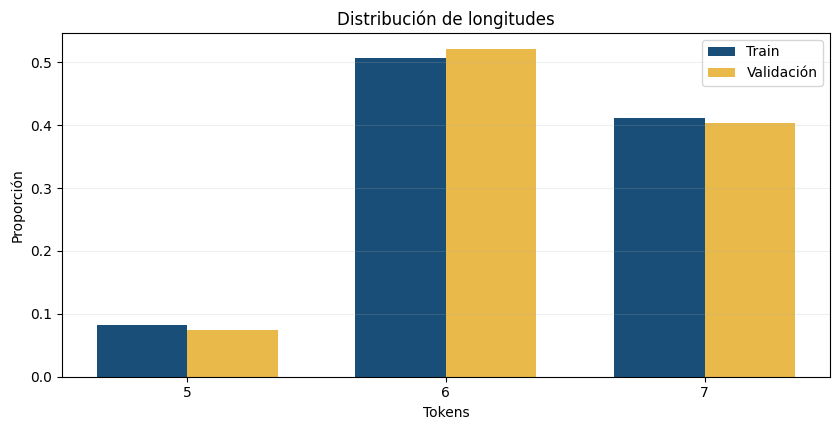

In [4]:
def largos(filas, columna):
    return [len(r[columna].split()) for r in filas]

lt_src, lv_src = largos(train, "idioma_secreto"), largos(validacion, "idioma_secreto")
lt_tgt, lv_tgt = largos(train, "espanol"), largos(validacion, "espanol")
conteos = {"train": Counter(lt_src), "validación": Counter(lv_src)}

mostrar_tabla(
    ["Partición", "Media", "Mediana", "Mínimo", "Máximo", "Distribución"],
    [("Train", f"{statistics.mean(lt_src):.2f}", statistics.median(lt_src), min(lt_src), max(lt_src), dict(sorted(conteos['train'].items()))),
     ("Validación", f"{statistics.mean(lv_src):.2f}", statistics.median(lv_src), min(lv_src), max(lv_src), dict(sorted(conteos['validación'].items())))],
)

fig, ax = plt.subplots(figsize=(8.5, 4.4))
x = [5, 6, 7]; ancho = .35
ax.bar([v-ancho/2 for v in x], [conteos['train'][v]/len(train) for v in x], ancho, label="Train", color="#184e77")
ax.bar([v+ancho/2 for v in x], [conteos['validación'][v]/len(validacion) for v in x], ancho, label="Validación", color="#e9b949")
ax.set_xticks(x); ax.set_xlabel("Tokens"); ax.set_ylabel("Proporción"); ax.set_title("Distribución de longitudes")
ax.legend(); ax.grid(axis="y", alpha=.2); fig.tight_layout()
fig.savefig(FIGURAS / "eda_longitudes.png", dpi=180, bbox_inches="tight"); plt.show()

<div class="eda-section"><h2>5 · Gramática y subgrupos de dificultad</h2></div>
<div class="eda-call">Se identifican negación, adjetivos y casos donde sujeto y objeto comparten determinante; este último elimina una pista superficial y exige usar la posición.</div>

Rasgo,Train n,Train %,Validación n,Validación %
negación,591,49.25%,115,47.92%
adjetivo,1005,83.75%,204,85.00%
mismo determinante,521,43.42%,116,48.33%


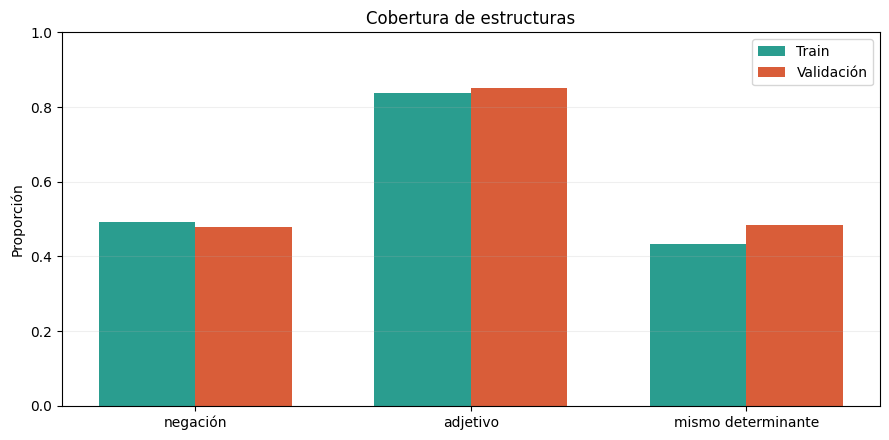

In [5]:
ADJETIVOS = {"azul", "feliz", "grande", "joven", "verde"}

def tiene_negacion(r):
    return "no" in r["espanol"].split()

def tiene_adjetivo(r):
    return bool(ADJETIVOS & set(r["espanol"].split()))

def mismo_determinante(r):
    t = r["espanol"].split()
    segundo = 4 if t[2] == "no" else 3
    return t[0] == t[segundo]

def resumen_estructura(filas):
    return {
        "negación": sum(tiene_negacion(r) for r in filas),
        "adjetivo": sum(tiene_adjetivo(r) for r in filas),
        "mismo determinante": sum(mismo_determinante(r) for r in filas),
    }

est_train, est_val = resumen_estructura(train), resumen_estructura(validacion)
mostrar_tabla(
    ["Rasgo", "Train n", "Train %", "Validación n", "Validación %"],
    [(k, est_train[k], f"{est_train[k]/len(train):.2%}", est_val[k], f"{est_val[k]/len(validacion):.2%}") for k in est_train],
)

fig, ax = plt.subplots(figsize=(9, 4.5))
rasgos = list(est_train); x = list(range(len(rasgos))); ancho=.35
ax.bar([v-ancho/2 for v in x], [est_train[k]/len(train) for k in rasgos], ancho, label="Train", color="#2a9d8f")
ax.bar([v+ancho/2 for v in x], [est_val[k]/len(validacion) for k in rasgos], ancho, label="Validación", color="#d95d39")
ax.set_xticks(x, rasgos); ax.set_ylim(0, 1); ax.set_ylabel("Proporción"); ax.set_title("Cobertura de estructuras")
ax.legend(); ax.grid(axis="y", alpha=.2); fig.tight_layout()
fig.savefig(FIGURAS / "eda_estructuras.png", dpi=180, bbox_inches="tight"); plt.show()

<div class="eda-call gold"><b>Hallazgo central.</b> El 48.33% de validación utiliza el mismo determinante para sujeto y objeto. En esos casos el artículo no ayuda a distinguir roles; el modelo debe apoyarse en la posición. Este subgrupo coincide con el patrón dominante de inversión sujeto–objeto observado en los errores.</div>

<div class="eda-section"><h2>6 · Resultados y errores del baseline</h2></div>
<div class="eda-call">Se conecta el EDA con la corrida congelada. No se seleccionan hiperparámetros nuevos en este notebook.</div>

In [6]:
RUTA_RESULTADOS = RAIZ / "resultados" / "resultados_lab5.json"
resultados = json.loads(RUTA_RESULTADOS.read_text(encoding="utf-8"))
pos = resultados["con_posicion"]
sin = resultados["sin_posicion"]

display(HTML(f"""
<div class='eda-grid'>
  <div class='eda-metric'><b>{pos['exactitud_tokens']:.2%}</b>Token con posición</div>
  <div class='eda-metric'><b>{pos['frases_exactas']:.2%}</b>Frases con posición</div>
  <div class='eda-metric'><b>{sin['exactitud_tokens']:.2%}</b>Token sin posición</div>
  <div class='eda-metric'><b>{sin['frases_exactas']:.2%}</b>Frases sin posición</div>
</div>"""))

errores = resultados["errores_muestra"]
mostrar_tabla(
    ["Idioma secreto", "Esperado", "Predicción"],
    [(e["secreto"], e["esperado"], e["prediccion"]) for e in errores],
)
print(f"Muestra documentada: {len(errores)} errores de 14 frases no exactas.")

Idioma secreto,Esperado,Predicción
fefo rino fefo sena gero pefe riga,el perro no lleva el niño verde,el niño no lleva el perro verde
moro seza moro povo mapa nava riga,la maestra no lee la médica grande,la médica no lee la maestra grande
fefo rino fefo sena gero zita riga,el perro no encuentra el niño verde,el niño no encuentra el perro verde
fefo mefi fefo disa gero rizo,el músico cuida el niño azul,el niño cuida el músico azul
moro somi moro ragi sesi gope riga,la niña no busca la gata joven,la gata no busca la niña joven
fefo zizi fefo ragi rino bane,el jardinero mira el perro joven,el perro mira el jardinero joven
moro somi moro mapa gope riga,la niña no busca la médica,la médica no busca la niña
fefo rino fefo disa mefi nava riga,el perro no lee el músico azul,el músico no lee el perro azul
moro somi moro sena sesi gope,la niña busca la gata verde,la gata busca la niña verde
fefo zizi fefo posi mefi zita riga,el jardinero no encuentra el músico feliz,el músico no encuentra el jardinero feliz


Muestra documentada: 10 errores de 14 frases no exactas.


<div class="eda-section"><h2>7 · Decisiones derivadas del EDA</h2></div>
<div class="eda-call">Los datos están limpios y completamente cubiertos; por ello, la siguiente iteración debe atacar asignación de roles y convergencia, no eliminar columnas ni ampliar vocabulario.</div>


<div class="eda-grid">
  <div class="eda-metric"><b>Conservar</b>Vocabulario y particiones</div>
  <div class="eda-metric"><b>Priorizar</b>Mismo determinante</div>
  <div class="eda-metric"><b>Probar</b>Más épocas y beam search</div>
  <div class="eda-metric"><b>Medir</b>Frase exacta primero</div>
</div>

### Recomendaciones antes de cambiar el modelo

1. Exportar predicciones de las 240 frases para medir exactitud por determinante, negación, adjetivo y largo.
2. Extender el baseline actual a 30–35 épocas porque la mejor pérdida con posición apareció en la época 22.
3. Probar beam search sin aumentar parámetros.
4. Solo después comparar configuraciones de 133k–226k parámetros.
5. Mantener frases exactas como métrica primaria, exactitud por token como secundaria y parámetros como desempate.

<div class="eda-call red"><b>Límite.</b> Este EDA orienta hipótesis, pero no demuestra que una configuración nueva ganará. Las decisiones finales requieren experimentos controlados sobre la misma validación y deben congelarse antes de las frases ocultas.</div>



<div class="eda-section"><h2>Referencias y trazabilidad</h2></div>

- Vaswani, A., et al. (2017). *Attention Is All You Need*. https://arxiv.org/abs/1706.03762
- PyTorch. (2026). *Transformer documentation*. https://docs.pytorch.org/docs/stable/generated/torch.nn.Transformer.html
- Datos asignados al Grupo 1 del Reto Babel: `diccionario.csv`, `entrenamiento.csv` y `validacion.csv`.
